# Feature Analysis – Heart Disease Dataset
*Risk Prediction project*  

---

## Table of Contents

<a id='imports'></a>
## Reproducibility & Imports  


In [40]:
# Reproducibility
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Imports
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('..', 'scripts')))

# Tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

SEED = 42

In [41]:
df = pd.read_csv('../data/df_prep_bal.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,0.636364,0,6.368187,0,0.112150,1,12.487489,0.888546,0.217391,1,0,0.000000,1
1,0.272727,0,7.155591,0,0.448598,0,12.481274,0.453505,0.478261,1,0,0.007117,1
2,0.454545,0,4.990433,0,0.112150,0,11.995358,0.576119,0.173913,1,1,0.010676,1
3,0.181818,1,4.718499,0,0.112150,0,12.254868,0.888546,0.521739,1,0,0.010676,1
4,0.454545,1,5.081404,1,0.112150,0,12.697719,1.000000,0.000000,0,0,0.014235,1


In [59]:
df_copy = df.copy()
TARGET_COL = 'DEATH_EVENT'

X = df_copy.drop(columns=[TARGET_COL])
y = df_copy[TARGET_COL]

----
## Feature Analysis and Selection

### Descriptive Statistics

**Goal:** Identify how the average feature values differ in 'DEATH_EVENT'.

In [43]:
# group by target and compute mean and std
summary = df.groupby(TARGET_COL).mean().round(2)
summary

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
DEATH_EVENT,,,,,,,,,,,,
0,0.34,0.41,5.58,0.42,0.49,0.33,12.43,0.45,0.53,0.65,0.33,0.55
1,0.45,0.44,5.71,0.36,0.36,0.36,12.39,0.65,0.46,0.64,0.29,0.24


### Correlation / Association Strength

**Goal:** To measure the strength and direction of association between each feature and the target variable (`num`).

In [44]:
corrs = df.corr(method="spearman")[TARGET_COL].sort_values(ascending=False)
corrs

DEATH_EVENT                 1.000000
serum_creatinine            0.416995
age                         0.243882
creatinine_phosphokinase    0.062120
high_blood_pressure         0.036336
anaemia                     0.029907
sex                        -0.015421
platelets                  -0.026821
smoking                    -0.042781
diabetes                   -0.055507
serum_sodium               -0.228639
ejection_fraction          -0.331478
time                       -0.582481
Name: DEATH_EVENT, dtype: float64

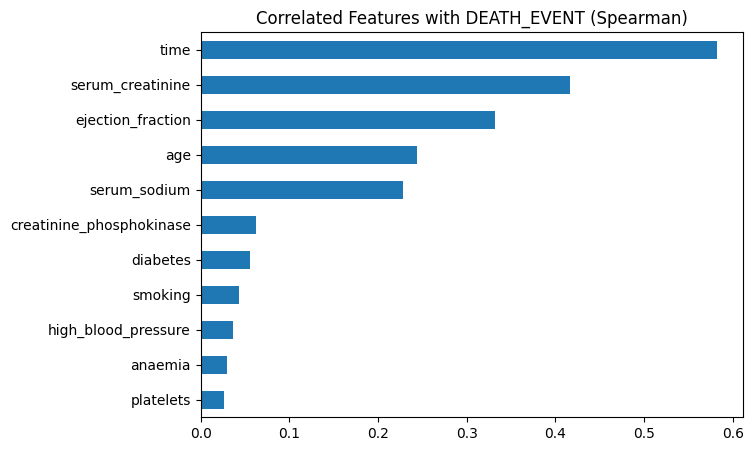

In [63]:
corr_abs = corrs.abs().sort_values(ascending=False)[1:12]
corr_abs.plot(kind="barh", figsize=(7,5), title="Correlated Features with DEATH_EVENT (Spearman)")
plt.gca().invert_yaxis()
plt.show()

### Feature Importance via Tree-Based Model

**Goal:** Determine which features contribute most to predicting heart disease severity using a tree-based (nonlinear) model.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

rf = RandomForestClassifier(random_state=SEED, n_estimators=500)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances

time                        0.327367
serum_creatinine            0.183074
ejection_fraction           0.128440
serum_sodium                0.079151
age                         0.077340
creatinine_phosphokinase    0.074316
platelets                   0.072299
diabetes                    0.012643
smoking                     0.012158
sex                         0.012012
anaemia                     0.011949
high_blood_pressure         0.009249
dtype: float64

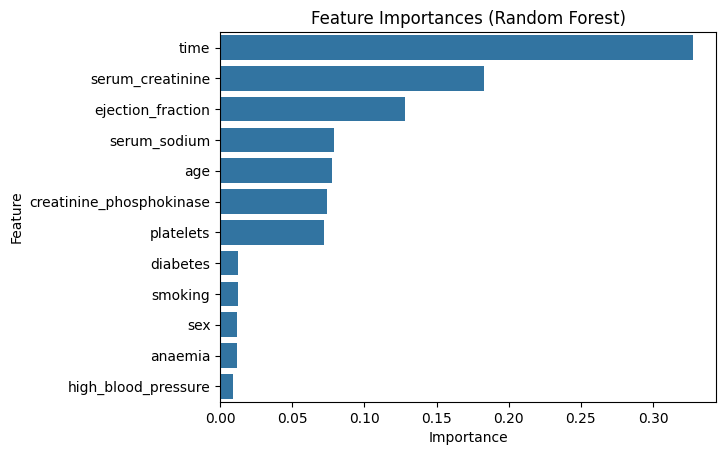

In [64]:
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### SHAP

### Statistical Tests 

#### Kruskal-Wallis
**Goal:** Test whether the distributions of each feature differ significantly across disease severity classes (`num` = 0–4).

In [48]:
# p_values = {}
# for col in X.columns:
#     groups = [X[col][y == i] for i in sorted(y.unique())]
#     stat, p = kruskal(*groups)
#     p_values[col] = p

# pd.Series(p_values).sort_values().head(10)

**Key findings:**
- All top features show **extremely low p-values (p < 1e-14)**, confirming **strong distributional differences** across classes.  
- **Oldpeak (p ≈ 2e-107)** — by far the most significant; clearly varies with disease severity.  
- **Chest pain type (cp)**, **age**, **exercise-induced angina (exang)**, and **maximum heart rate (thalch)** also exhibit highly significant variation (p < 1e-45).  
- **Sex**, **dataset**, **restecg**, **fbs**, and **chol** remain significant but with slightly weaker evidence, still well below typical α = 0.05.  

**Interpretation:**  
The Kruskal–Wallis results statistically confirm that **multiple physiological features differ systematically with disease progression**, especially **oldpeak**, **cp**, and **age**.  
Together with prior analyses, this validates that **heart disease severity is driven by complex, nonlinear patterns**, where certain features (e.g., oldpeak, age, cp) consistently show both statistical and predictive importance.

#### Chi-square (categorical × categorical)

**Goal:** Assess associations between categorical variables using Chi-square tests and estimate the strength of the association.

In [49]:
# out, n = [], len(df)

# for a, b in combinations(categorical_columns, 2):
#     ct = pd.crosstab(df_clean[a], df_clean[b])
#     if ct.shape[0] < 2 or ct.shape[1] < 2: 
#         continue
#     chi2, p, _, _ = chi2_contingency(ct)
#     k = min(ct.shape[0]-1, ct.shape[1]-1)
#     assoc = (np.sqrt(chi2/n) if ct.shape == (2,2) else np.sqrt(chi2/(n*k)))
#     out.append([a, b, p, assoc])

# chi_df = pd.DataFrame(out, columns=['var_a','var_b','p','assoc']).sort_values('p')
# chi_df['p_adj'] = multipletests(chi_df['p'], method='fdr_bh')[1]
# chi_df.sort_values('p_adj')


In [50]:
# chi_df_sig = chi_df[chi_df['p_adj'] <= 0.05].sort_values('p_adj', ascending=True)
# chi_df_sig

**Key findings:**  
Significant associations (p_adj ≤ 0.05) include:

| Variable A | Variable B | p-value | p_adj | Association strength |
|------------|------------|---------|-------|----------------------|
| dataset    | fbs        | 3.59e-104 | 7.54e-103 | 0.52 (strong)        |
| dataset    | slope      | 1.34e-84  | 1.41e-83  | 0.39 (moderate)      |
| dataset    | restecg    | 1.80e-72  | 1.26e-71  | 0.36 (moderate)      |
| exang      | slope      | 5.32e-54  | 2.79e-53  | 0.38 (moderate)      |
| dataset    | exang      | 6.04e-49  | 2.54e-48  | 0.36 (moderate)      |
| cp         | exang      | 2.61e-36  | 9.12e-36  | 0.31 (moderate)      |

**Interpretation:**  
- Strongest association: **dataset vs fbs** (Cramér's V = 0.52).
- Other associations are **weak to moderate** (Cramér's V ≤ 0.39).
- Findings suggest interdependencies between variables that may impact model performance.

#### Q–Q Plots (Normality check)
**Goal:** Assess how closely each numeric variable follows a normal distribution using Q–Q plots.

In [51]:
# plt.figure(figsize=(20, 6))
# plt.subplots_adjust(left=0, bottom=0, right=0.8, top=1, wspace=0.3, hspace=0.4)

# for i, c in enumerate(numerical_columns, 1):
#     ax = plt.subplot(2, 4, i)
#     (osm, osr), (slope, intercept, _) = stats.probplot(df_clean[c].dropna(), dist="norm")
#     ax.plot(osm, osr, 'o', markersize=3)
#     ax.plot(osm, slope*osm + intercept, 'r-', linewidth=1)
#     ax.set_title(f'Q-Q Plot | {c}')
#     ax.set_xlabel('Theoretical quantiles'); ax.set_ylabel('Ordered Values')

# plt.show()

**Key findings:**
- `age`, `trestbps`, `chol`: points close to the line → ~normal; mild tail deviations.
- `thalch`: mostly linear with slight tail curvature → near-normal.
- `oldpeak`: strong positive skew / stepped values → not normal.
- `num` (target): discrete/ordinal; far from the line → not normal (not continuous).

**Interpretation:**
- Parametric assumptions are reasonable for age, trestbps, chol (and cautiously thalch).
- Use transformations/robust or non-parametric methods for oldpeak.
- Treat num as categorical/ordinal, not a normally distributed continuous variable.

#### Shapiro–Wilk Normality Test

**Goal:** Test whether each numeric variable is normally distributed.

In [52]:
# rows = []
# for c in X:
#     s = df[c].dropna()
#     if len(s) >= 3:
#         w, p = stats.shapiro(s)
#         rows.append([c, p])
# pd.DataFrame(rows, columns=['feature','sw_p_value'])

**Key findings:**
- `age`: p = 2.27e-05 → reject normality.
- `trestbps`: p = 6.15e-11 → reject normality.
- `chol`: p = 7.69e-08 → reject normality.
- `thalch`: p = 1.59e-05 → reject normality.
- `oldpeak`: p = 3.22e-29 → strong non-normality.
- nu`m: p = 3.57e-32 → strong non-normality (discrete/ordinal).

**Interpretation:**
- At α = 0.05, all variables deviate from normality.
- Use robust/transformations (e.g., log/Box-Cox for skewed continuous vars) or non-parametric tests.
- Treat num as categorical/ordinal, not continuous normal.
- If sample size is large, tiny p-values are common—consider Q–Q plots and effect on your chosen models/tests.

#### One-way ANOVA (DV ~ Factor)
**Goal:** Test mean differences of each numeric DV across categorical factor levels; control multiple testing with BH–FDR.

In [53]:
# rows = []
# for y in numerical_columns:
#     for g in categorical_columns:
#         sub = df_clean[[y, g]].dropna()
#         sub[g] = sub[g].astype('category')
#         vc = sub[g].value_counts()
#         model = ols(f'Q("{y}") ~ C(Q("{g}"))', data=sub).fit()
#         an = sm.stats.anova_lm(model, typ=2)
#         p = float(an['PR(>F)'].iloc[0])
#         rows.append([y, g, p])

# ANOVA_df = pd.DataFrame(rows, columns=['DV','Factor','p_raw']).sort_values('p_raw')

# reject, p_adj, *_ = multipletests(ANOVA_df['p_raw'], method='fdr_bh')
# ANOVA_df['p_adj'] = p_adj
# ANOVA_df['significant'] = reject
# print("ANOVA rows:", len(ANOVA_df))
# ANOVA_df


In [54]:
# ANOVA_sig_fdr = (ANOVA_df.query('significant').sort_values('p_adj', ascending=True).reset_index(drop=True))
# ANOVA_sig_raw = (ANOVA_df.query('p_raw <= 0.05').sort_values('p_raw', ascending=True).reset_index(drop=True))

In [55]:
# ANOVA_sig_fdr

In [56]:
# ANOVA_sig_raw

---
## Visual Validation of Key Feature Trends


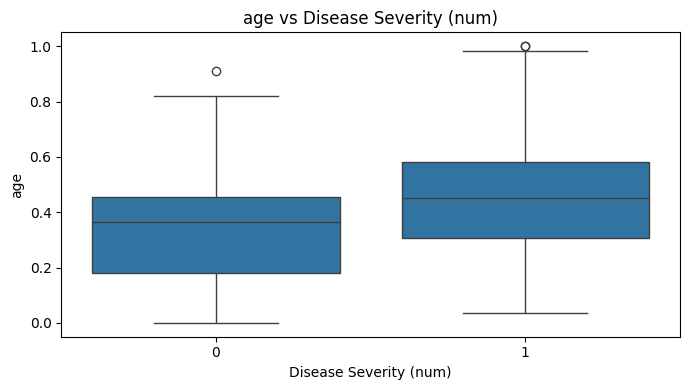

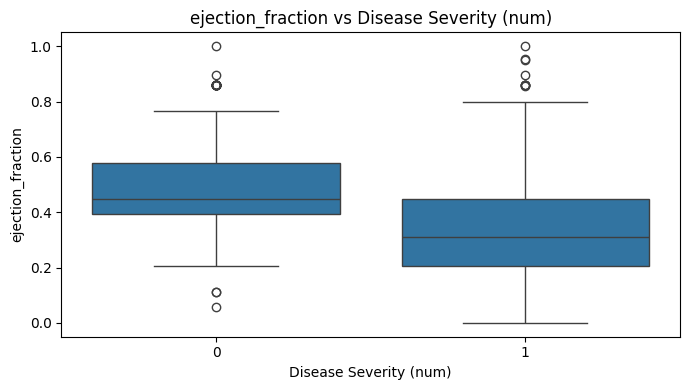

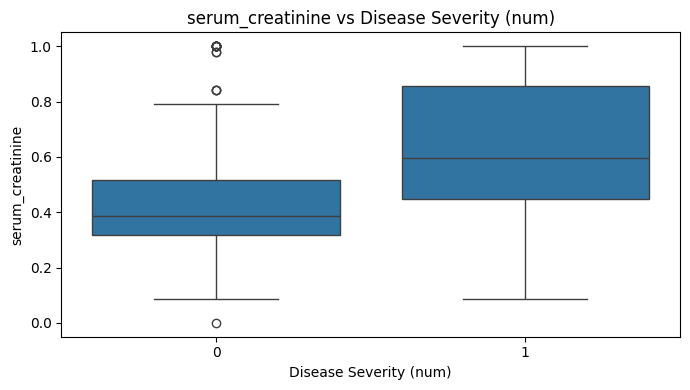

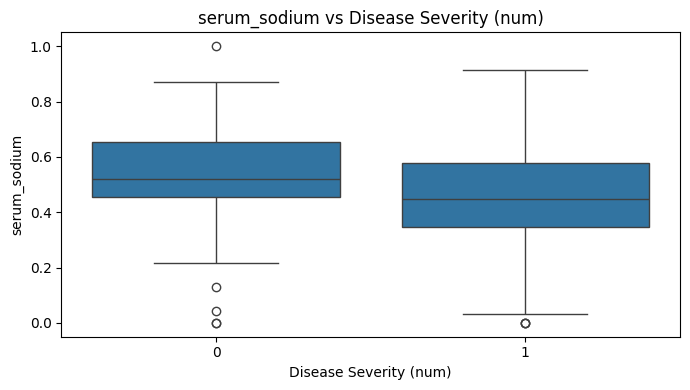

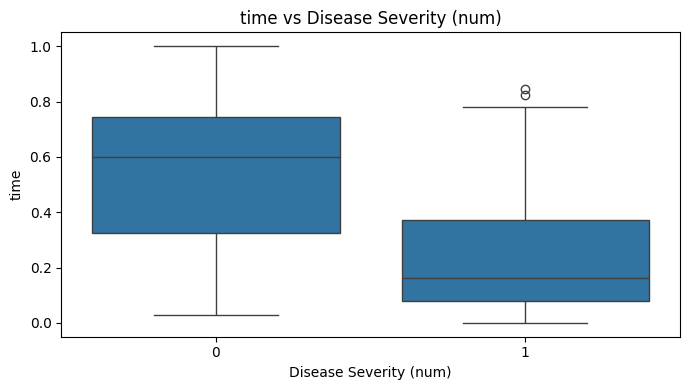

In [57]:
top_features = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'time']

for feature in top_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=TARGET_COL, y=feature, data=df)
    plt.title(f"{feature} vs Disease Severity (num)", fontsize=12)
    plt.xlabel("Disease Severity (num)")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()
